In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("/home/shadowrc/Downloads/titanic.csv")


In [2]:
df['Age'] =df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Ticket','Fare','Cabin','Name','PassengerId'])

df['Sex'] = df['Sex'].map({'male' : 0,'female': 1})

df=df.dropna()

print(df.shape)
print(df.head())
print(df.columns)

(889, 7)
   Survived  Pclass  Sex   Age  SibSp  Parch Embarked
0         0       3    0  22.0      1      0        S
1         1       1    1  38.0      1      0        C
2         1       3    1  26.0      0      0        S
3         1       1    1  35.0      1      0        S
4         0       3    0  35.0      0      0        S
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked'], dtype='str')


In [3]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})


x = df.drop(columns=['Survived'])
y =df['Survived']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size =0.2,random_state =42)


print("training size " ,x_train.shape)
print("testing size" ,x_test.shape)

training size  (711, 6)
testing size (178, 6)


In [4]:
model = LogisticRegression()

model.fit(x_train,y_train)

y_predict = model.predict(x_test)

print("Accuracy : ",accuracy_score(y_test,y_predict)*100)

Accuracy :  78.65168539325843


In [5]:
passenger = pd.DataFrame({'Pclass':[3],'Sex':[0] ,'Age':[35],'SibSp':[0], 'Parch':[0],'Embarked':[0]})


prediction = model.predict(passenger)
probability = model.predict_proba(passenger)

print("Survived" if prediction[0] == 1 else "Died")
print(f"Survival Probability : {probability[0][1]*100}")

Died
Survival Probability : 7.478109895971643


In [6]:
cm = confusion_matrix(y_test,y_predict)
print(cm)


[[87 22]
 [16 53]]


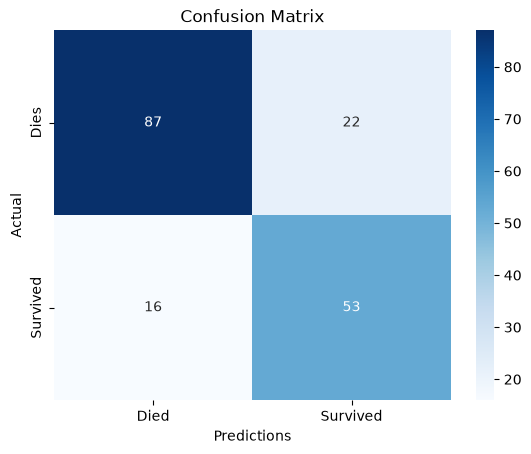

In [7]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Died','Survived'],yticklabels=['Dies','Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.show()

In [8]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       109
           1       0.71      0.77      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

dt_pred = dt_model.predict(x_test)

print("Decision Tree Accuracy : ",accuracy_score(y_test,dt_pred)*100)
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy :  78.65168539325843
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       109
           1       0.72      0.74      0.73        69

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



In [10]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)

rf_pred = rf_model.predict(x_test)

print("Random Forest Accuracy : ",accuracy_score(y_test,rf_pred)*100)
print(classification_report(y_test, rf_pred))


Random Forest Accuracy :  81.46067415730337
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       109
           1       0.76      0.75      0.76        69

    accuracy                           0.81       178
   macro avg       0.81      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178

